# NHS Antidepressant Prescribing in England: A Five-Year Analysis (2021–2025)
## The Data Science Workshop Project Notebook

**Facilitator:** Damilola Ogungbemi | MSc Biotechnology | Health Data Scientist  
**Data Source:** NHS Business Services Authority -  Prescription Cost Analysis (PCA) Monthly Data  
**Period Covered:** January 2021 to December 2025  



### How to use this notebook

This notebook is your guided workbook for the two-day workshop. Your job is to:

1. **Pay close attention and follow along**
2.  **Run each cell** by clicking the play button or pressing Shift + Enter
3.  **Read the explanation** above each cell before running it
4. **Look at the output** and think about what it is telling you
5. **Write in the markdown cells** where you are asked to - those are your thinking spaces



---
# Learning Outcome 1: Define the Question
### Why this step matters

Before you open a dataset, before you write a single line of code, you need a question. Not a topic, a question.


### Our project question

For this workshop, our research question is:

> **How has antidepressant prescribing in England changed between 2021 and 2025 — in terms of volume, cost, drug type, and regional variation — and what do these patterns mean for NHS planning and mental health policy?**

This question is directly relevant to two  NHS priorities:
1. The NHS 10 Year Health Plan, which identifies mental health as a national priority
2. The NHS 2025/26 operational goal to reduce unwarranted variation in prescribing across regions



### Your turn

In the cell below, write your own answer to this question:  
**What is one question from your own field or daily life that you think could be answered with data?**  
Do not worry about whether the data exists yet. Just write the question.

 **Your question:**

> How much time is wasted at the hospitals because of the absence of a harmonised electronic health records system in Ghana?


---
# Learning Outcome 2: Find and Source the Data

### Why this step matters

You don't always need to collect your own data to run a data project. Governments, researchers, and institutions have already collected more data than anyone could analyse in a lifetime and most of it is free and publicly available.


---
# Learning Outcome 3: Understand and Explore the Data

### Why this step matters

Before you analyse anything, you need to understand what you are actually working with.




### Our dataset

| | |
|---|---|
| **Source** | NHS Business Services Authority — PCA Monthly Data |
| **URL** | opendata.nhsbsa.net/dataset/prescription-cost-analysis-pca-monthly-data |
| **Coverage** | January 2021 to December 2025 |
| **Scope** | Antidepressants only (BNF Chapter 4, Section 3) |
| **Rows** | 12,000+ |
| **Columns** | 6 |
| **Format** | CSV |





### Data dictionary

| Column | Type | Description |
|---|---|---|
| YEAR | integer | The calendar year |
| YEAR_MONTH | integer | Year and month combined, e.g. 202101 = January 2021 |
| REGION_NAME | text | One of the 7 NHS England regions |
| BNF_CHEMICAL_SUBSTANCE | text | The drug name, e.g. Sertraline hydrochloride |
| ITEMS | integer | Number of prescription items dispensed that month |
| COST | decimal | Total cost to the NHS in pounds sterling (Net Ingredient Cost) |

**Important note:** COST here refers to Net Ingredient Cost (NIC) — the cost of the drug ingredient itself, not the dispensing fee. It is what the NHS paid for the medicine.

---
#IMPORT DATA

In [ ]:
# STEP 1: Import the tools/libraries we need
# pandas handles data manipulation, matplotlib and seaborn handle charts and visualisation.
# Keeping imports minimal is good practice — only bring in what you need.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all charts
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")


Libraries loaded successfully


In [ ]:
# STEP 2: Load the dataset

# We load the data directly from a URL so everyone gets exactly the same file
#without needing to download anything.

# gdown is a tool that lets us read files from Google Drive.

import gdown

# This is the unique ID of the file on Google Drive
file_id = "1QzDmu65_jimGHFBse8JfQpa_U1scVwIW"

gdown.download(id=file_id,
               output="workshop_data.csv",
               quiet=False)

# Load it into pandas — a DataFrame is like a spreadsheet in Python
df = pd.read_csv('workshop_data.csv')

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Downloading...
From: https://drive.google.com/uc?id=1QzDmu65_jimGHFBse8JfQpa_U1scVwIW
To: /content/workshop_data.csv
100%|██████████| 715k/715k [00:00<00:00, 103MB/s]

Dataset loaded successfully
Shape: 12,330 rows x 6 columns


In [ ]:
# STEP 3: First look - what does the data actually look like?

# head() shows us the first 5 rows.
# This is usually the first thing you do after loading data.
# This shows the names of the columns.

df.head()

,YEAR,YEAR_MONTH,REGION_NAME,BNF_CHEMICAL_SUBSTANCE,ITEMS,COST
0,2021,202101,EAST OF ENGLAND,Agomelatine,183,7405.37
1,2021,202101,EAST OF ENGLAND,Amitriptyline hydrochloride,153891,320331.06
2,2021,202101,EAST OF ENGLAND,Citalopram hydrobromide,163948,219490.05
3,2021,202101,EAST OF ENGLAND,Citalopram hydrochloride,752,12357.66
4,2021,202101,EAST OF ENGLAND,Clomipramine hydrochloride,2824,22170.92


In [ ]:
# STEP 4: Check data types

# dtypes tells us what Python thinks each column is.
# This is critical — e.g. a date stored as a number cannot be plotted on a timeline.
# A number stored as text cannot be added up.
#
# Look at YEAR_MONTH — it shows as int64 (an integer).
# But we know 202101 means January 2021. It is a date, not a number.
# We will fix this in the cleaning step.

print("Column data types:")
print(df.dtypes)

Column data types:
YEAR                        int64
YEAR_MONTH                  int64
REGION_NAME                object
BNF_CHEMICAL_SUBSTANCE     object
ITEMS                       int64
COST                      float64
dtype: object


In [ ]:

# STEP 5: Statistical summary

# describe() gives us a quick statistical profile of all numeric columns.
# Look at the min, max, and mean for ITEMS and COST.
# If you see anything that looks impossible e.g: a negative cost, a zero quantity
# that is a quality problem we need to investigate.

df.describe()

,YEAR,YEAR_MONTH,ITEMS,COST
count,12330.000000,12330.000000,12330.000000,1.233000e+04
mean,2022.996431,202306.140633,35953.414112,9.662236e+04
std,1.414954,141.542674,72454.963542,1.698050e+05
min,2021.000000,202101.000000,-999.000000,1.100000e+00
25%,2022.000000,202203.000000,160.000000,6.331555e+03
50%,2023.000000,202306.000000,1740.000000,3.393367e+04
75%,2024.000000,202409.000000,25672.000000,1.085167e+05
max,2025.000000,202512.000000,536819.000000,2.721513e+06


In [ ]:
# STEP 6: Understand what is in the dataset

# How many years? How many regions? How many drugs?
# This confirms we have the data we expected before going any further.

print(f"Years covered: {sorted(df['YEAR'].astype(int).unique().tolist())}")
print(f"Number of months: {df['YEAR_MONTH'].nunique()}")
print(f"Number of regions: {df['REGION_NAME'].nunique()}")
print(f"Number of drugs: {df['BNF_CHEMICAL_SUBSTANCE'].nunique()}")

Years covered: [2021, 2022, 2023, 2024, 2025]
Number of months: 60
Number of regions: 7
Number of drugs: 32


### Your observations

Before moving on, write your answers to these three questions:

 **What I noticed about this dataset:**
> It is a large dataset.

 **Anything that looks unusual or surprising:**
> Year is an integer instead of a date.

 **A question this data has raised for me:**
> Write here

---
# Learning Outcome 4: Clean and Prepare the Data

### Why this step matters
Data is almost always dirty. You need to clean the data before you can trust the insights and outputs you get from it.


In [ ]:
# CLEANING DIAGNOSTIC — Answer all 5 questions first

# We diagnose before we treat.
# Run this cell and read every output carefully before fixing anything.


print("QUESTION 1: Are data types correct?")
print(df.dtypes)
print("\n------------------------------------------------")

print("QUESTION 2: Missing values?")
print(df.isnull().sum())
print("\n------------------------------------------------")

print("QUESTION 3: Duplicate rows?")
print(f"Duplicate rows found: {df.duplicated().sum()}")
print("\n------------------------------------------------")

print("QUESTION 4: Category consistency?")
print(f"Unique drug names: {df['BNF_CHEMICAL_SUBSTANCE'].nunique()}")
print(f"Unique regions: {df['REGION_NAME'].nunique()}")
print("\n------------------------------------------------")

print("QUESTION 5: Impossible values?")
print(f"Negative ITEMS: {(df['ITEMS'] < 0).sum()}")
print(f"Negative COST: {(df['COST'] < 0).sum()}")
print(f"Zero ITEMS: {(df['ITEMS'] == 0).sum()}")

QUESTION 1: Are data types correct?
YEAR                        int64
YEAR_MONTH                  int64
REGION_NAME                object
BNF_CHEMICAL_SUBSTANCE     object
ITEMS                       int64
COST                      float64
dtype: object

------------------------------------------------
QUESTION 2: Missing values?
YEAR                      0
YEAR_MONTH                0
REGION_NAME               0
BNF_CHEMICAL_SUBSTANCE    3
ITEMS                     0
COST                      0
dtype: int64

------------------------------------------------
QUESTION 3: Duplicate rows?
Duplicate rows found: 1

------------------------------------------------
QUESTION 4: Category consistency?
Unique drug names: 32
Unique regions: 7

------------------------------------------------
QUESTION 5: Impossible values?
Negative ITEMS: 1
Negative COST: 0
Zero ITEMS: 0


In [ ]:
# FIX 1: Convert YEAR_MONTH to a proper date

# 202101 is an integer, but it represents January 2021.
# Python cannot sort, plot, or group by month until we fix this.
# We convert it to a proper datetime format.

df['YEAR_MONTH'] = pd.to_datetime(
    df['YEAR_MONTH'].astype(str),  # Convert integer to string first
    format='%Y%m'                   # Tell Python: year then month, no separator
)


print(f"New type: {df['YEAR_MONTH'].dtype}")
print(f"Sample values: {df['YEAR_MONTH'].head(3).tolist()}")

ValueError: time data "2021-01-01" doesn't match format "%Y%m", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# FIX 2: Handle missing values

# If a row has no drug name, we cannot group it or analyse it meaningfully.
# We drop those rows and document exactly what we did and why.
#
# Rule: always record how many rows you removed.
# Dropping data is a decision, not a reflex.

rows_before = len(df)

# Drop rows where drug name is missing — we cannot use unnamed drugs
df = df.dropna(subset=['BNF_CHEMICAL_SUBSTANCE'])

rows_after = len(df)
print(f"Rows before: {rows_before:,}")
print(f"Rows after: {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before: 12,330
Rows after: 12,327
Rows removed: 3


In [ ]:

# FIX 3: Remove duplicate rows


rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print(f"Duplicate rows removed: {rows_before - rows_after}")
print(f"Clean shape: {df.shape}")

Duplicate rows removed: 1
Clean shape: (12326, 6)


In [ ]:

# FIX 4: Remove impossible values

# A negative number of prescription items is not possible in reality.
# If we see one, it is a data error — not something we should analyse.

rows_before = len(df)
df = df[df['ITEMS'] > 0]
rows_after = len(df)

print(f"Rows with impossible values removed: {rows_before - rows_after}")
print(f"Final clean shape: {df.shape}")

Rows with impossible values removed: 0
Final clean shape: (12325, 6)


In [ ]:
# SAVE THE CLEAN DATA

# Always save your cleaned data as a separate file.
# Do not overwrite your raw data.


df.to_csv('nhs_antidepressants_clean.csv', index=False)
print("Clean dataset saved")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Clean dataset saved
Final shape: 12,325 rows x 6 columns


### Cleaning summary; always document your decisions

A professional analysis always documents what was changed and why. Complete this table.

 **What I found and what I did:**

| Issue found | What I did | Why |
|---|---|---|
| YEAR_MONTH stored as integer | Converted to datetime | So Python can sort and group by month |
| There were missing values | We deleted the rows with missing values | This is to be able to analyse the data effectively |

---
# Learning Outcome 5: Analyse the Data

### Why this step matters

This is where we start answering the question we defined in Step 1. The data is clean and trustworthy. Now we use it.

The principle here is: **start general, then go granular.**


In [ ]:

# ANALYSIS 1: National picture — total items per year

# groupby is one of the most powerful tools in data analysis.
# In this case it answers: "for each YEAR, what is the total number of ITEMS?"

# Group the data by YEAR
yearly = df.groupby('YEAR')[['ITEMS', 'COST']].sum().reset_index()

# Convert to millions for readability
yearly['items_millions'] = (yearly['ITEMS'] / 1_000_000).round(2)
yearly['cost_millions'] = (yearly['COST'] / 1_000_000).round(2)

# Show the results
print("Annual antidepressant prescribing in England:")
print(yearly[['YEAR', 'items_millions', 'cost_millions']])


Annual antidepressant prescribing in England:
   YEAR  items_millions  cost_millions
0  2021           82.61         288.03
1  2022           85.40         224.65
2  2023           88.47         230.01
3  2024           92.12         226.70
4  2025           94.69         221.78


In [ ]:

# ANALYSIS 2: Top 10 drugs by volume

# Now we zoom in from national totals to drug-level details.
# Which specific drugs are being prescribed the most?


top_volume = (
    df.groupby('BNF_CHEMICAL_SUBSTANCE')['ITEMS']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_volume.columns = ['drug', 'total_items']
top_volume['items_millions'] = (top_volume['total_items'] / 1_000_000).round(2)

print("Top 10 antidepressants by prescriptions (2021-2025):")
print(top_volume[['drug', 'items_millions']].to_string(index=False))

Top 10 antidepressants by prescriptions (2021-2025):
                       drug  items_millions
   Sertraline hydrochloride          115.00
Amitriptyline hydrochloride           78.45
    Citalopram hydrobromide           68.03
                Mirtazapine           62.20
   Fluoxetine hydrochloride           37.05
                Venlafaxine           28.83
   Duloxetine hydrochloride           20.04
               Escitalopram            9.03
    Trazodone hydrochloride            6.48
   Paroxetine hydrochloride            6.35


In [ ]:

# ANALYSIS 3: Top 10 drugs by cost

# Now the same question — but from a cost perspective.
# Are the most prescribed drugs also the most expensive?


top_cost = (
    df.groupby('BNF_CHEMICAL_SUBSTANCE')['COST']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_cost.columns = ['drug', 'total_cost']
top_cost['cost_millions'] = (top_cost['total_cost'] / 1_000_000).round(2)

print("Top 10 antidepressants by cost to NHS (2021-2025):")
print(top_cost[['drug', 'cost_millions']].to_string(index=False))

Top 10 antidepressants by cost to NHS (2021-2025):
                       drug  cost_millions
   Sertraline hydrochloride         263.66
                Venlafaxine         210.08
Amitriptyline hydrochloride         115.22
   Fluoxetine hydrochloride          97.24
    Citalopram hydrobromide          88.80
                Mirtazapine          79.35
   Duloxetine hydrochloride          73.72
               Vortioxetine          41.03
       Trimipramine maleate          28.30
    Tranylcypromine sulfate          26.98


In [ ]:

# ANALYSIS 4: Regional breakdown

# Same groupby principle — different column.
# Once you understand groupby, you can apply it to any dimension.
#
# We also calculate cost per item which is a derived metric.
# Derived metrics (cost divided by items) often reveal more than raw numbers.
# This tells you: how efficient is each region's prescribing?

regional = df.groupby('REGION_NAME')[['ITEMS', 'COST']].sum().reset_index()
regional['items_millions'] = (regional['ITEMS'] / 1_000_000).round(2)
regional['cost_millions'] = (regional['COST'] / 1_000_000).round(2)
regional['cost_per_item'] = (regional['COST'] / regional['ITEMS']).round(2)
regional = regional.sort_values('items_millions', ascending=False)

print("Regional prescribing summary (2021-2025):")
print(regional[['REGION_NAME', 'items_millions', 'cost_millions', 'cost_per_item']].to_string(index=False))

Regional prescribing summary (2021-2025):
             REGION_NAME  items_millions  cost_millions  cost_per_item
NORTH EAST AND YORKSHIRE           98.00         227.51           2.32
                MIDLANDS           83.55         226.56           2.71
              NORTH WEST           66.04         168.26           2.55
              SOUTH EAST           55.33         182.33           3.30
         EAST OF ENGLAND           50.90         136.04           2.67
                  LONDON           47.06         131.22           2.79
              SOUTH WEST           42.43         119.25           2.81


In [ ]:

# ANALYSIS 5: Monthly prescribing trend

# Instead of looking at yearly totals, we now look at the data
# month by month to see how prescribing changes over time.

import matplotlib.dates as mdates
# Group the data by month
monthly = df.groupby('YEAR_MONTH')[['ITEMS', 'COST']].sum().reset_index()

# Convert to millions for easier reading
monthly['items_millions'] = (monthly['ITEMS'] / 1_000_000).round(2)
monthly['cost_millions'] = (monthly['COST'] / 1_000_000).round(2)

print("Monthly prescribing summary")
print(monthly.head())

Monthly prescribing summary
  YEAR_MONTH    ITEMS         COST  items_millions  cost_millions
0 2021-01-01  6709771  30206003.33            6.71          30.21
1 2021-02-01  6337698  28472592.72            6.34          28.47
2 2021-03-01  7129148  31933609.64            7.13          31.93
3 2021-04-01  6895434  24695554.55            6.90          24.70
4 2021-05-01  6597509  23672108.18            6.60          23.67


---
## Learning Outcome 6: Visualise the Findings

### Why this step matters

Data visualisation turns numbers into charts and graphs, making it much easier to understand the data. It helps you quickly spot patterns, trends, and unusual values that might be hard to see in a table of numbers.




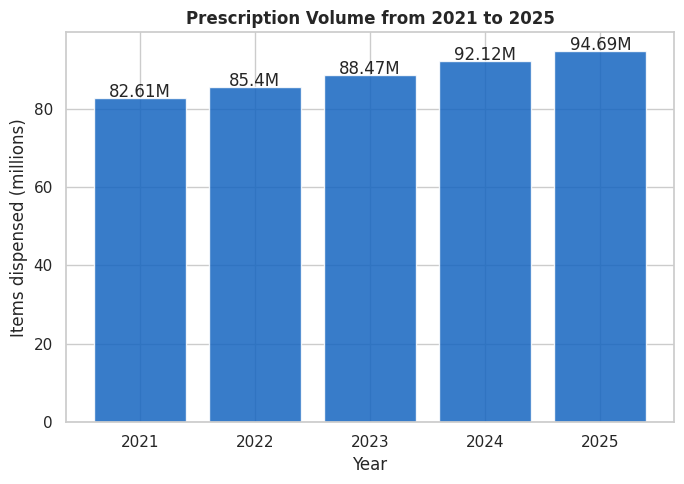

In [ ]:

# CHART 1: Prescription Volume


plt.figure(figsize=(7, 5))

plt.bar(
    yearly['YEAR'],
    yearly['items_millions'],
    color='#1565C0',
    alpha=0.85
)

plt.title('Prescription Volume from 2021 to 2025', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Items dispensed (millions)')

# Add value labels
for _, row in yearly.iterrows():
    plt.text(
        row['YEAR'],
        row['items_millions'] + 0.3,
        f"{row['items_millions']}M",
        ha='center'
    )

plt.tight_layout()
plt.show()

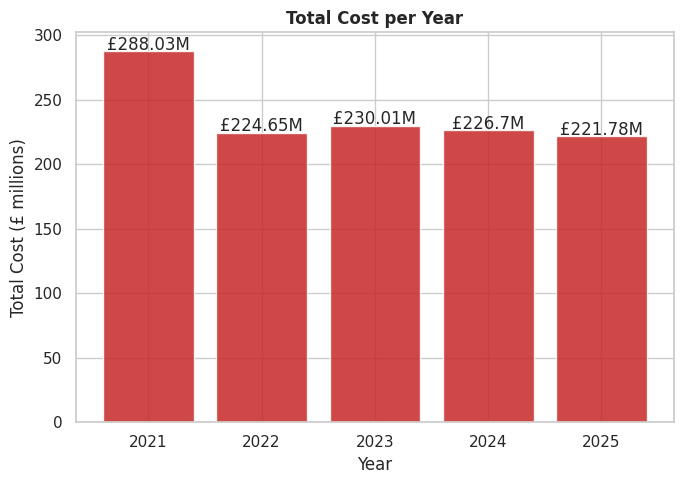

In [ ]:

# CHART 2: Total Cost


plt.figure(figsize=(7, 5))

plt.bar(
    yearly['YEAR'],
    yearly['cost_millions'],
    color='#C62828',
    alpha=0.85
)

plt.title('Total Cost per Year', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Cost (£ millions)')

# Add value labels
for _, row in yearly.iterrows():
    plt.text(
        row['YEAR'],
        row['cost_millions'] + 1,
        f"£{row['cost_millions']}M",
        ha='center'
    )

plt.tight_layout()
plt.show()

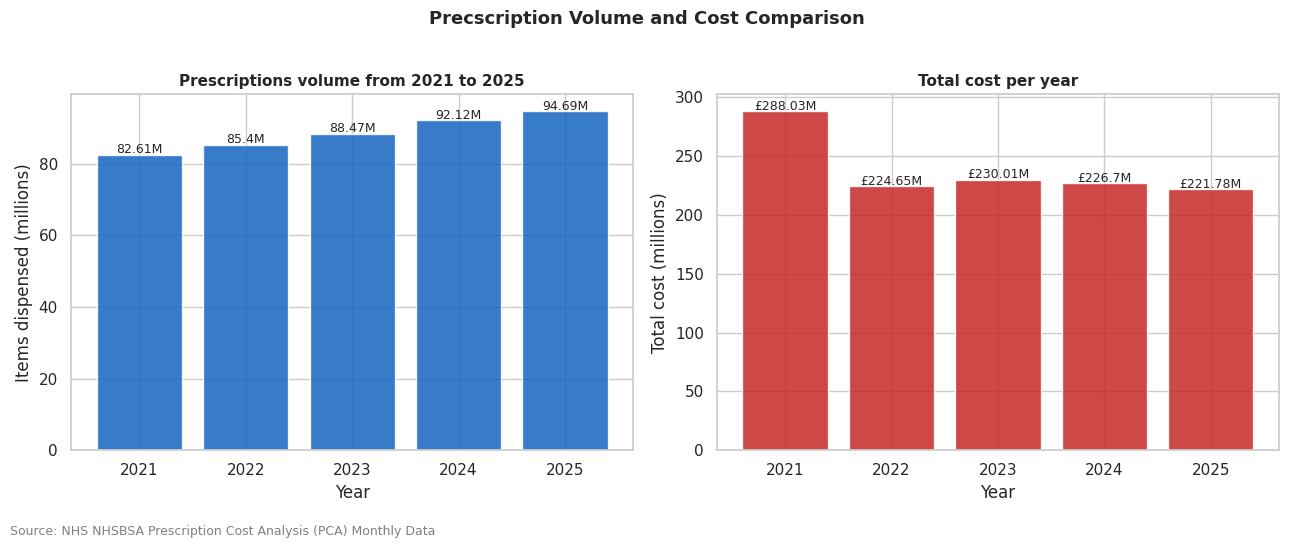

In [ ]:
# CHART 1: National trend — volume and cost side by side

# Two charts next to each other let us compare patterns directly.
# We are looking for whether volume and cost tell the same story — or different ones.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Volume
ax1.bar(yearly['YEAR'], yearly['items_millions'],
        color='#1565C0', alpha=0.85)
ax1.set_title('Prescriptions volume from 2021 to 2025',
              fontweight='bold', fontsize=11)
ax1.set_ylabel('Items dispensed (millions)')
ax1.set_xlabel('Year')

# Add value labels on each bar
for _, row in yearly.iterrows():
    ax1.text(row['YEAR'], row['items_millions'] + 0.3,
             f"{row['items_millions']}M", ha='center', fontsize=9)

# Chart 2: Cost
ax2.bar(yearly['YEAR'], yearly['cost_millions'],
        color='#C62828', alpha=0.85)
ax2.set_title('Total cost per year',
              fontweight='bold', fontsize=11)
ax2.set_ylabel('Total cost (millions)')
ax2.set_xlabel('Year')

for _, row in yearly.iterrows():
    ax2.text(row['YEAR'], row['cost_millions'] + 1,
             f"£{row['cost_millions']}M", ha='center', fontsize=9)

# Overall title and source
fig.suptitle('Precscription Volume and Cost Comparison',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.01, -0.03,
         'Source: NHS NHSBSA Prescription Cost Analysis (PCA) Monthly Data',
         fontsize=9, color='grey')

plt.tight_layout()

plt.show()


### Your observations


**What did you notice:**
> Write here


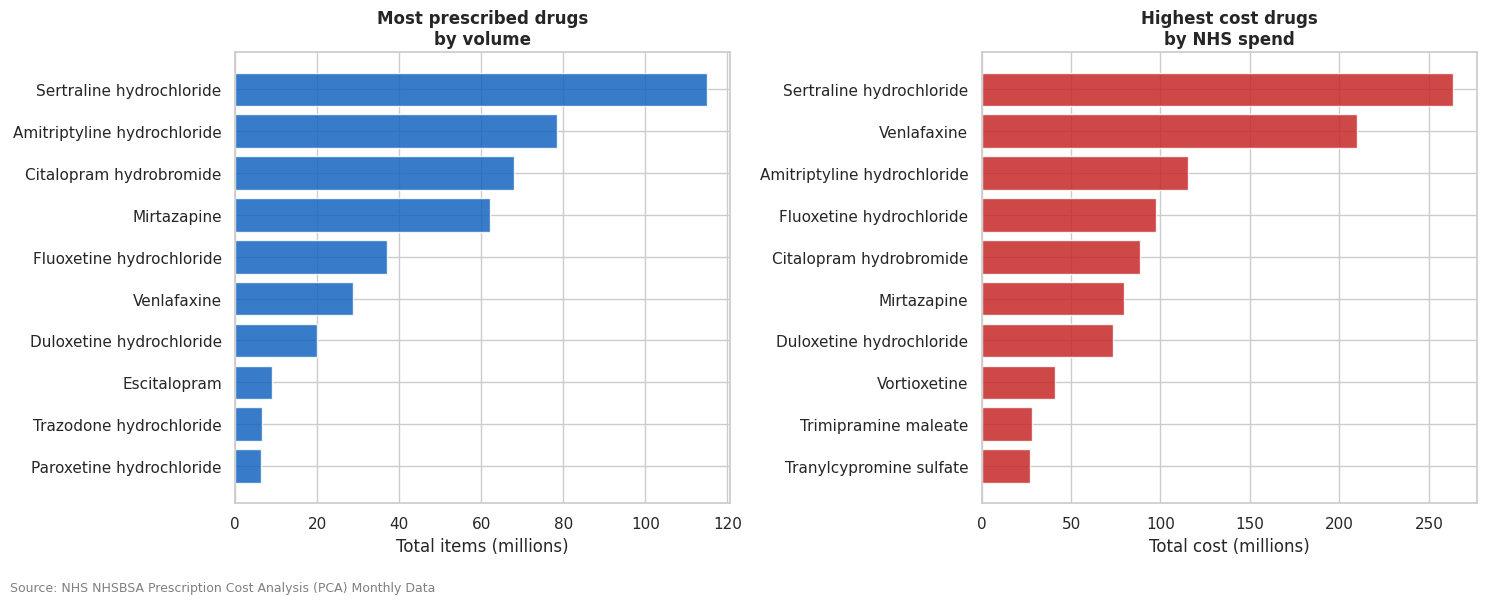

In [ ]:

# CHART 2: Volume vs cost — do the same drugs top both lists?


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Volume chart — horizontal bar for readability of long drug names
ax1.barh(top_volume['drug'][::-1],
         top_volume['total_items'][::-1] / 1_000_000,
         color='#1565C0', alpha=0.85)
ax1.set_title('Most prescribed drugs\nby volume', fontweight='bold')
ax1.set_xlabel('Total items (millions)')

# Cost chart
ax2.barh(top_cost['drug'][::-1],
         top_cost['total_cost'][::-1] / 1_000_000,
         color='#C62828', alpha=0.85)
ax2.set_title('Highest cost drugs\nby NHS spend', fontweight='bold')
ax2.set_xlabel('Total cost (millions)')

fig.suptitle('',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.01, -0.03,
         'Source: NHS NHSBSA Prescription Cost Analysis (PCA) Monthly Data',
         fontsize=9, color='grey')

plt.tight_layout()

plt.show()


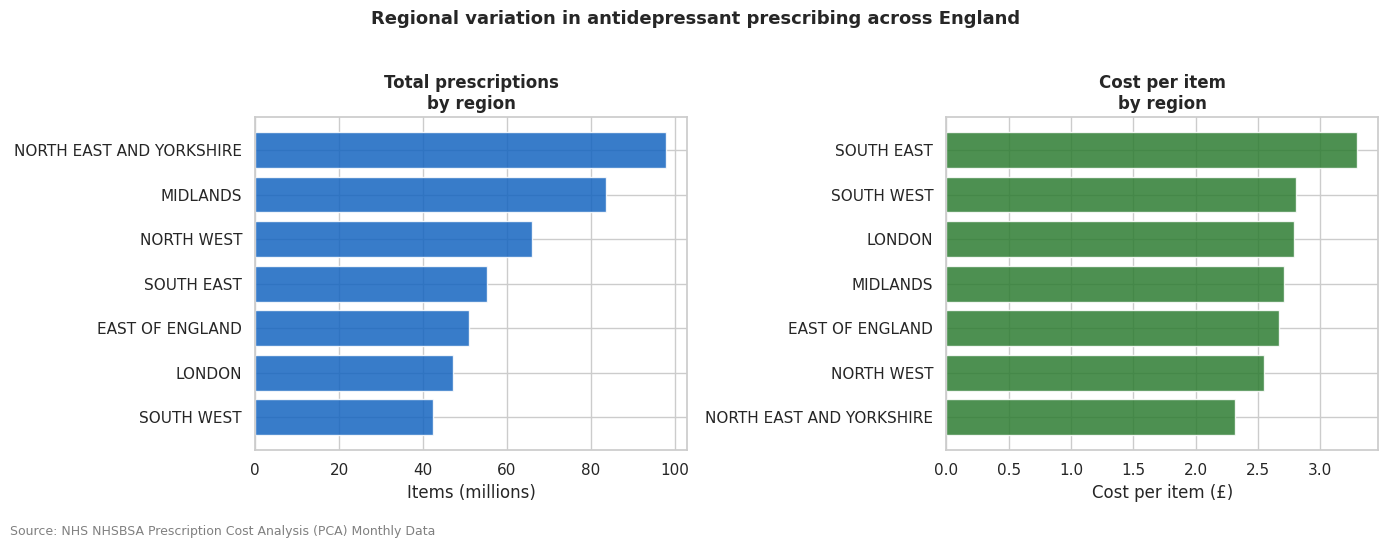

In [ ]:

# CHART 3: Regional variation
# what is different in each region

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

r_vol = regional.sort_values('items_millions')
ax1.barh(r_vol['REGION_NAME'], r_vol['items_millions'],
         color='#1565C0', alpha=0.85)
ax1.set_title('Total prescriptions\nby region', fontweight='bold')
ax1.set_xlabel('Items (millions)')

r_cpi = regional.sort_values('cost_per_item')
ax2.barh(r_cpi['REGION_NAME'], r_cpi['cost_per_item'],
         color='#2E7D32', alpha=0.85)
ax2.set_title('Cost per item\nby region', fontweight='bold')
ax2.set_xlabel('Cost per item (£)')

fig.suptitle('Regional variation in antidepressant prescribing across England',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.01, -0.03,
         'Source: NHS NHSBSA Prescription Cost Analysis (PCA) Monthly Data',
         fontsize=9, color='grey')

plt.tight_layout()

plt.show()


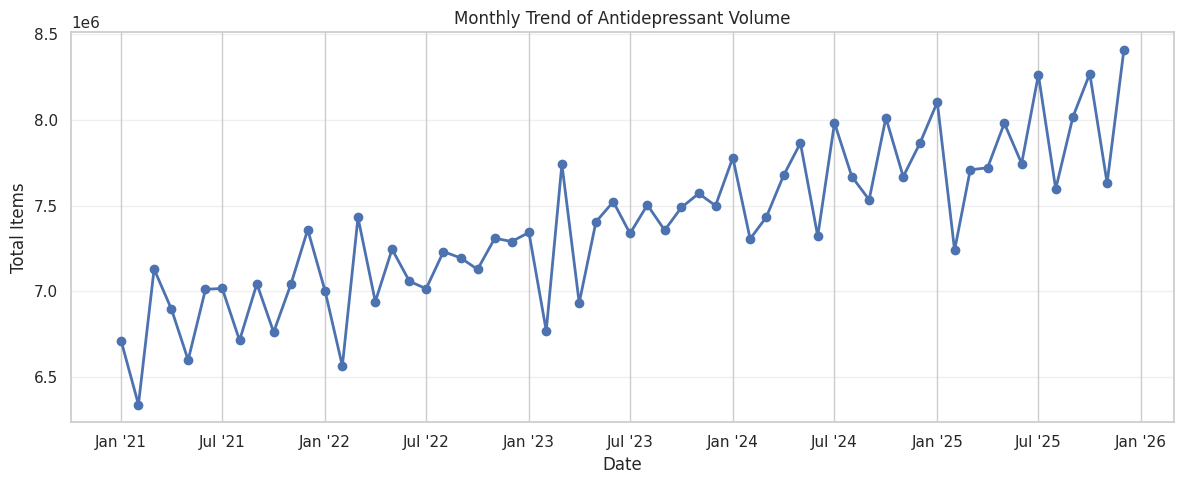

In [ ]:

# CHART 4: Monthly Trend of Antidepressant Volume


import matplotlib.dates as mdates

plt.figure(figsize=(12,5))

plt.plot(
    monthly["YEAR_MONTH"],
    monthly["ITEMS"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Trend of Antidepressant Volume")
plt.xlabel("Date")
plt.ylabel("Total Items")

# Show labels every 6 months
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))


plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# CHART 5: Monthly Trend of Antidepressant Cost


import matplotlib.dates as mdates

plt.figure(figsize=(12,5))

plt.plot(
    monthly["YEAR_MONTH"],
    monthly["COST"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Trend of Antidepressant Costs")
plt.xlabel("Date")
plt.ylabel("Total cost")

# Show labels every 6 months
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))


plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---
## Learning Outcome 7: Interpret and Communicate Findings

explain what you found in clear sentences

### Key Findings

 **Finding 1 - National volume trend:**
> Write here

 **Finding 2 - The cost trend:**
> Write here

 **Finding 3 - Volume vs cost by drug:**
> Write here

 **Finding 4 - Regional variation:**
> Write here

 **Finding 5 - Monthly Trends:**
> Write here

---
## Learning Outcome 8: Document, Publish and Share

### Why this step matters

A project that exists only on your laptop does not exist. Publishing your work is what turns a personal project into a professional contribution.

GitHub is where data scientists, researchers, and engineers store and share their work publicly. A well-structured GitHub repository tells the world: here is the question I asked, here is the data I used, here is what I found.

### Your repository structure

Create a folder on your GitHub with this structure:

```
nhs-antidepressant-analysis/
├── README.md                        <- The front page of your project
├── notebook/
│   └── nhs_antidepressant_analysis.ipynb
├── data/
│   ├── raw/                         <- Original file, never modified
│   └── processed/                   <- Your clean CSV
└── images/
    ├── chart_01_national_trend.png
    ├── chart_02_volume_vs_cost.png
    └── chart_03_regional.png
```


